In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy.cluster import hierarchy
from collections import defaultdict
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2
import imp
from utils import load_animal_region_kernels, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, load_animal_prior
from matplotlib.colors import Normalize
from metric import dsd


/tmp/ipykernel_1741478/4235935003.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


### Testing profile of kernels

In [2]:
genotypes = ['N', 'C', 'F', 'S']
genotype = 'C'
regions = list_regions(genotype)
animals = list_animals(genotype)

animal = 'CSP013'
region = 'MOs'

animal_kernel_region = load_animal_region_kernels(genotype, animal, region) # Give kernals across all units of this region
animal_kernel = load_animal_kernels(genotype, regions, animal) # Give kernals across all units contrasts and time (n_units, n_contrasts, n_time_bins)


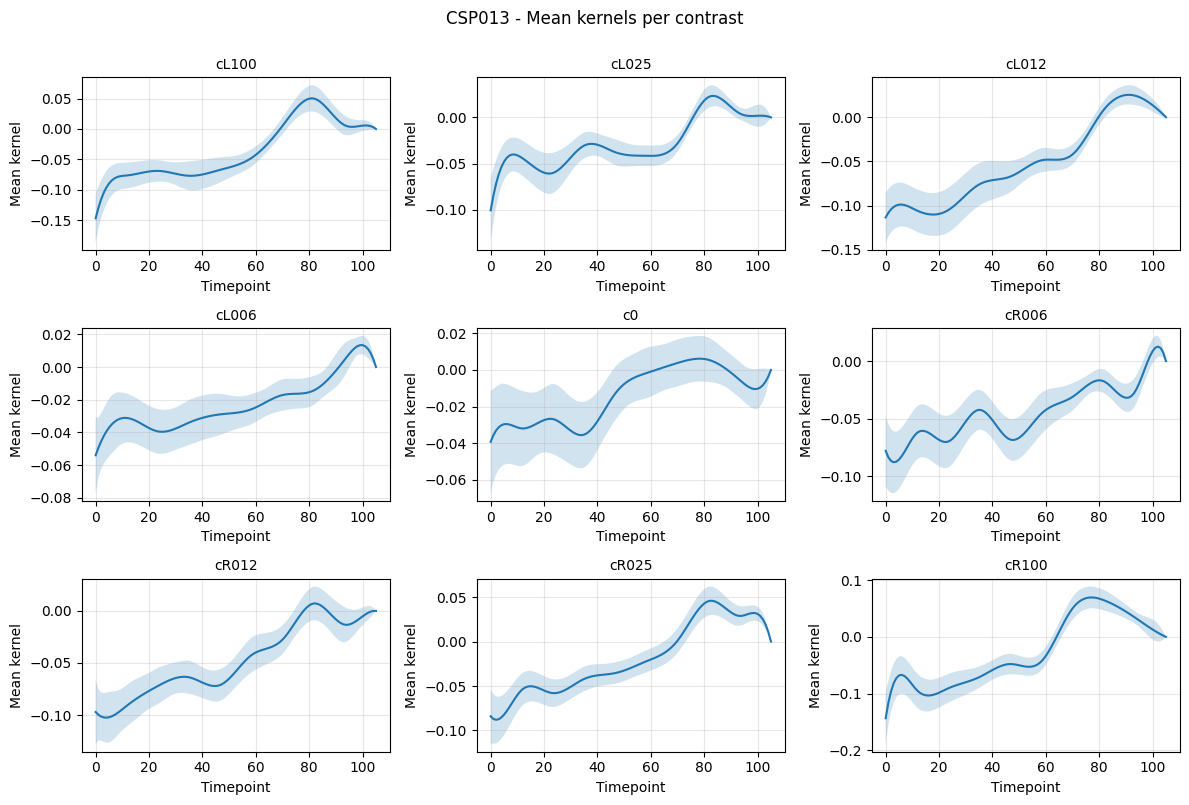

In [3]:
contrast_names = ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

animal_kernel_filter = filter_kernels_outliers(animal_kernel)
for c_idx, contrast in enumerate(contrast_names):
    kernel_contrast = animal_kernel_filter[:, c_idx, :]
    mean_kernel = kernel_contrast.mean(axis=0)
    
    axes[c_idx].plot(mean_kernel, linewidth=1.5)
    sem = kernel_contrast.std(axis=0) / np.sqrt(kernel_contrast.shape[0])
    axes[c_idx].fill_between(np.arange(len(mean_kernel)), mean_kernel - sem, mean_kernel + sem, alpha=0.2)
    axes[c_idx].set_title(contrast, fontsize=10)
    axes[c_idx].grid(True, alpha=0.3)
    axes[c_idx].set_xlabel('Timepoint')
    axes[c_idx].set_ylabel('Mean kernel')

plt.suptitle(f'{animal} - Mean kernels per contrast', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

### Across all subjects/genptypes

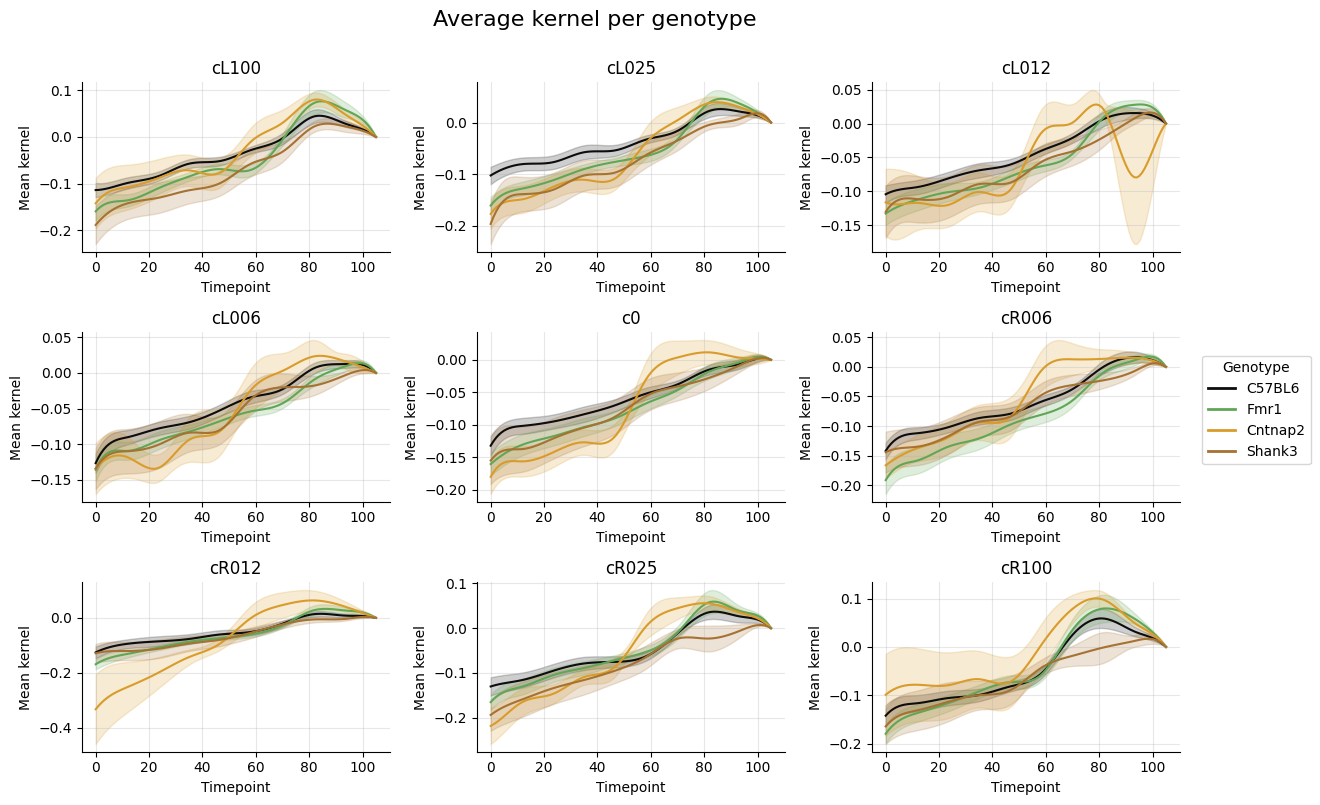

In [2]:
# Plot average kernel per genotype across all regions 

genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:
        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)

# Plot mean kernel across animals for each genotype and contrast - ignoring per-region and just agregating genotype
for c_idx, contrast in enumerate(contrast_names):
    ax = axes[c_idx]
    for g in genotypes:
        arrs = genotype_kernels_neurons[g]
        if len(arrs) == 0:
            continue
        vals = np.stack([a[:, c_idx, :].mean(axis=0) for a in arrs if len(a) > 0], axis=0) # (subjects, timepoints) for contrast c_idx
        mean = vals.mean(axis=0) # (n_units, timepoints)
        sem = vals.std(axis=0) / np.sqrt(vals.shape[0])
        ax.plot(mean, label=g, color=colors[g], linewidth=1.5)
        ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, color=colors[g], alpha=0.2)
    ax.set_title(contrast, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Mean kernel')

handles = [Line2D([0], [0], color=colors[g], lw=2) for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
labels = [map_labels[g] for g in genotypes if len(genotype_kernels_neurons[g]) > 0]
plt.suptitle('Average kernel per genotype', fontsize=16, y=1.00)
plt.tight_layout()
sns.despine()
fig.legend(handles=handles, labels=labels, title='Genotype', bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

In [5]:
genotype_kernels_neurons['C'][3].shape

(550, 9, 106)

## Shape metrics

### Functions

In [3]:
def plot_pca(dist_matrix, labels):

    # PCA on distance matrix
    pca_2d = PCA(n_components=2)
    pca_coords = pca_2d.fit_transform(dist_matrix)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding')
    ax.legend()

    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_mds_pca(dist_matrix, labels, n_components=50, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    #mds_coords = (mds_coords - mds_coords.mean(axis=0)) / mds_coords.std(axis=0)

    # PCA on MDS coordinates
    pca_2d = PCA(n_components=2, random_state=42)
    pca_coords = pca_2d.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA on MDS embedding', fontsize=13, fontweight='bold')
    ax.legend()

    return ax

def plot_mds_tsne(dist_matrix, labels, n_components=50, perplexity=20, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    # TSNE on MDS coordinates
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    tsne_coords = tsne.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # TSNE on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)
    ax.set_title('TSNE on MDS embedding', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_xlabel('tSNE1')
    ax.set_ylabel('tSNE2')

    return ax

In [4]:
# 106 time points is a lot for clustering, maybe I can split them into 10 bins and average within each bin to reduce dimensionality and noise?
def split_time_bins(arr, n_bins=10):
    """Split the last dimension of arr into n_bins and average within each bin."""
    if arr.shape[-1] % n_bins != 0:
        arr = arr[:, :, :-(arr.shape[-1] % n_bins)] # Trim the last dimension to be divisible by n_bins
    return arr.reshape(*arr.shape[:-1], n_bins, -1).mean(-1)

In [12]:
### Statistical tests

# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

def permutation_test(dist_matrix, labels, n_perms=1000):

    # Null hypothesis: the distance between genotypes is not different from the distance within genotypes

    S = len(labels)

    # Masks for within/between genotype distances
    within_mask = labels[None,:] == labels[None,:].T
    between_mask = labels[None, :] != labels[None,:].T

    obs_stat = dist_matrix[between_mask].mean() - dist_matrix[within_mask].mean()

    # Permutation null distribution
    perm_stats = np.zeros(n_perms)
    for k in range(n_perms):
        perm_labels = np.random.permutation(labels)

        # Permute the masks according to the permuted labels
        wm = perm_labels[None,:] == perm_labels[None,:].T
        bm = perm_labels[None, :] != perm_labels[None,:].T

        perm_stats[k] = dist_matrix[bm].mean() - dist_matrix[wm].mean()

    p_value = np.mean(perm_stats >= obs_stat)
    print(f"Observed statistic (between - within): {obs_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    return p_value, perm_stats, obs_stat

def per_genotype_stat(dist_matrix, labels, g):
    mask_g = labels == g
    within = dist_matrix[np.ix_(mask_g, mask_g)] 
    within_vals = within[np.triu_indices(within.shape[0], 1)]
    between_vals = dist_matrix[np.ix_(mask_g, ~mask_g)].flatten()
    if len(within_vals) == 0 or len(between_vals) == 0:
        return np.nan
    return between_vals.mean() - within_vals.mean()

def get_distance_records(dist_matrix, labels):
    records = []
    S_fc = dist_matrix.shape[0]
    for i in range(S_fc):
        for j in range(i + 1, S_fc):
            if labels[i] == labels[j]:
                records.append({'genotype': labels[i], 'kind': 'within', 'distance': dist_matrix[i, j]})
            else:
                records.append({'genotype': labels[i], 'kind': 'between', 'distance': dist_matrix[i, j]})
                records.append({'genotype': labels[j], 'kind': 'between', 'distance': dist_matrix[i, j]})
    return records


def within_distance(dist_matrix, labels, genotype):
    mask_g = labels == genotype
    within = dist_matrix[np.ix_(mask_g, mask_g)]
    return within[np.triu_indices(within.shape[0], 1)]

def across_distance(dist_matrix, labels, g1, g2):
    mask_g1 = labels == g1
    mask_g2 = labels == g2
    return dist_matrix[np.ix_(mask_g1, mask_g2)].flatten()


In [141]:


def plot_dendogram(dist_neural, labs, save=False, lab_to_color=None, title=False):
    
    S = dist_neural.shape[0]
    
    dist_neural_flat = dist_neural[np.triu_indices(S,1)] #squareform(dist_neural)

    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    fig = plt.figure(figsize=(4,5))
    # Plot all together in the same figure...
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.02)

    ax_dendro = fig.add_subplot(gs[0])
    ax_heatmap = fig.add_subplot(gs[1])

    dn = hierarchy.dendrogram(
        linkage, 
        ax=ax_dendro, 
        color_threshold=0, 
        above_threshold_color='k'
    )
    ax_dendro.axis('off')

    leaf_order = hierarchy.leaves_list(
        hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    )
    if lab_to_color is None:
        unique_labs = np.unique(labs)
        cmap = plt.get_cmap('tab10') 
        lab_to_color = {lab: cmap(i / len(unique_labs)) for i, lab in enumerate(unique_labs)}

    x_coords = np.arange(5, S * 10 + 5, 10)

    for i, original_idx in enumerate(leaf_order):
        lab = labs[original_idx]
        color = lab_to_color[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=60, zorder=10, clip_on=False)

    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    
    ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto', 
                      vmin=np.min(ordered_dist), vmax=np.max(ordered_dist))

    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])

    if title:
        plt.title('Distance matrix with dendrogram ordering', fontsize=12, y=1.2)
    
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)

    if save:
        plt.savefig(f"distance_dendrogram.png", dpi=300, bbox_inches='tight')
    
    plt.show()

### Using the 100 most variable neurons

In [91]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    if len(arrs) == 0:
        continue
        
    # Get the 100 least variable neurons across all animals for this genotype and contrast
    vals = [a[np.argsort(a.std(axis=(1,2)))[-100:], :, :] for a in arrs if len(a) >= 100] # (neurons, contrasts, timepoints) for each subject

    if g=='C':
        # Remove the first subject of C because it has a very different activity and messes with the clustering
        vals.pop(3)

    # spLIT ACROSS TIME BINS
    #vals = [split_time_bins(a) for a in vals]

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.append(vals)

all_subjects = np.concatenate(all_subjects, axis=0) # (subjects, neurons, contrasts, timepoints)
S, n, c, t = all_subjects.shape
all_subjects_reshaped = all_subjects.reshape(S, n, c*t).transpose(0,2,1) # (subjects, contrast*timepoints, neurons)
#all_subjects_reshaped = all_subjects.mean(-1).transpose(0,2,1) # (subjects, contrast, neurons)

In [92]:
all_subjects_reshaped.shape

(34, 954, 100)

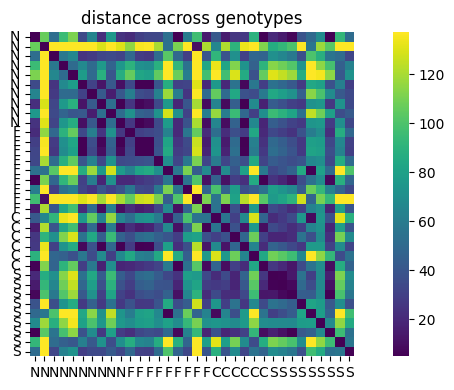

In [93]:
from matplotlib.colors import Normalize

from metric import dsd
S = len(all_subjects_reshaped)
dist_neural = dsd([
    [all_subjects_reshaped[i],all_subjects_reshaped[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

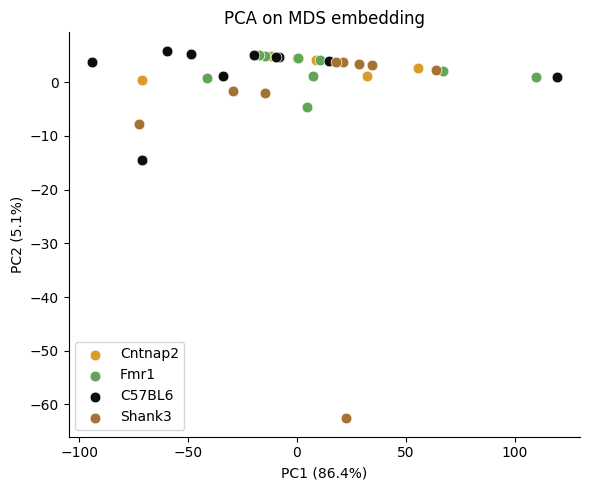

In [94]:
plot_mds_pca(dist_neural, all_genotypes)

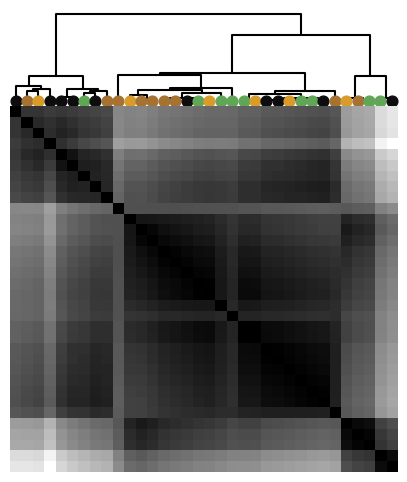

In [95]:
labels_arr = np.array(all_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors)

### Using all neurons

In [117]:
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    arrs = [a[:,3:6,:] for a in arrs] #[:,3:6,:]
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    vals = [a.reshape(a.shape[0], -1).T for a in arrs if len(a) >= 100] # (n_neurons, contrast*timepoints) for each subject

    # Maybe do a mean across all time points?
    #vals = [a.mean(-1).T for a in arrs if (len(a) >= 100) ] # (n_neurons, contrast) for each subject
    if g=='N':
        # Remove this subject of N because it has a very different activity and messes with the clustering
        vals.pop(-1)

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)


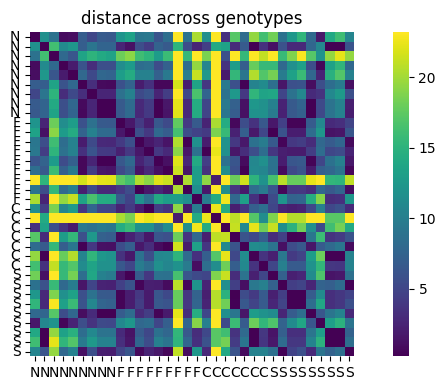

In [109]:

S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i], all_subjects[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'PCA on MDS embedding'}, xlabel='PC1 (82.5%)', ylabel='PC2 (14.2%)'>

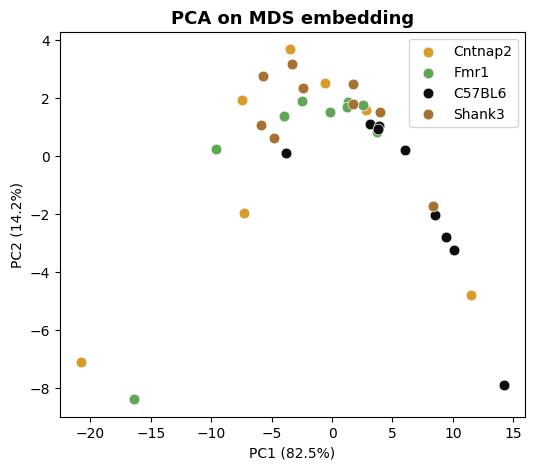

In [110]:
plot_mds_pca(dist_neural, all_genotypes)

<Axes: title={'center': 'TSNE on MDS embedding'}, xlabel='tSNE1', ylabel='tSNE2'>

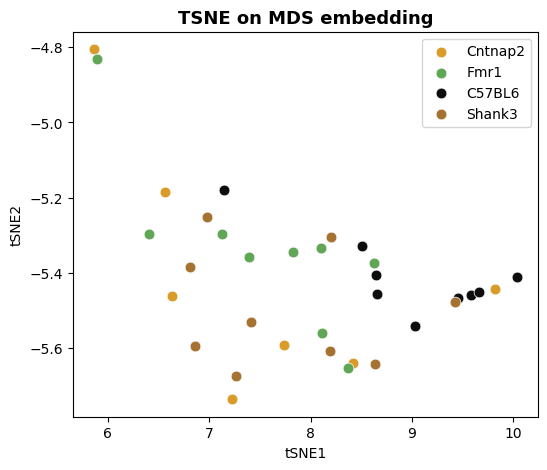

In [111]:
plot_mds_tsne(dist_neural, all_genotypes, perplexity=25)


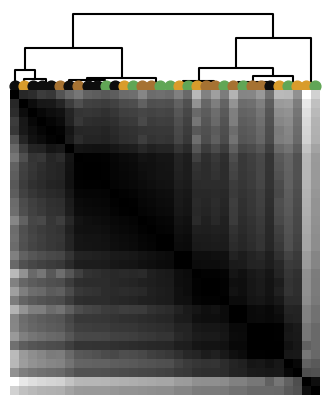

In [142]:
labels_arr = np.array(all_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors, title=False, save=True)

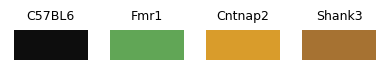

In [151]:

colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

# plot the color and the labels of the genotypes ans a 4 row by 1 column figure
fig, axes = plt.subplots(1, 4, figsize=(4,.8))

for i, (genotype, color) in enumerate(colors.items()):
    axes[i].bar(0, 1, color=color)
    axes[i].set_title(map_labels[genotype], fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"genotype_colors.svg", dpi=300, bbox_inches='tight')
plt.show()

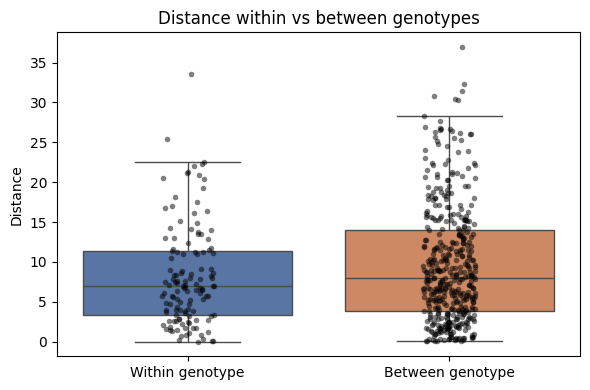

In [114]:
# Here, I want to see: are the distances between genotypes significantly higher than the distances within genotypes?

labels_arr = np.array(all_genotypes)
same_genotype = labels_arr[None,:] == labels_arr[None,:].T
diff_genotype = labels_arr[None, :] != labels_arr[None,:].T

S = len(labels_arr)
up_tri = np.triu_indices(S,1)

# Take just the upper part of the dist matrix
same_gen_indices = np.where(same_genotype[up_tri])
diff_gen_indices = np.where(diff_genotype[up_tri])

same_gen_distances = dist_neural[up_tri][same_gen_indices]
diff_gen_distances = dist_neural[up_tri][diff_gen_indices]

# To test the significance of this, I can do a permutation test where i:
# shuffle the labels
# recompute the same/different masks 
# compute the difference in mean distance between same and different genotypes

# Then i compare this null distrib to the observed difference  ---- implemented in another plot

plt.figure(figsize=(6,4))
sns.stripplot(data=[same_gen_distances, diff_gen_distances], color='black', alpha=0.5, size=4, jitter=True)
sns.boxplot(data=[same_gen_distances, diff_gen_distances], palette=['#4C72B0', '#DD8452'], showfliers=False)

plt.xticks([0, 1], ['Within genotype', 'Between genotype'])
plt.ylabel('Distance')
plt.title('Distance within vs between genotypes')
plt.tight_layout()
plt.show()


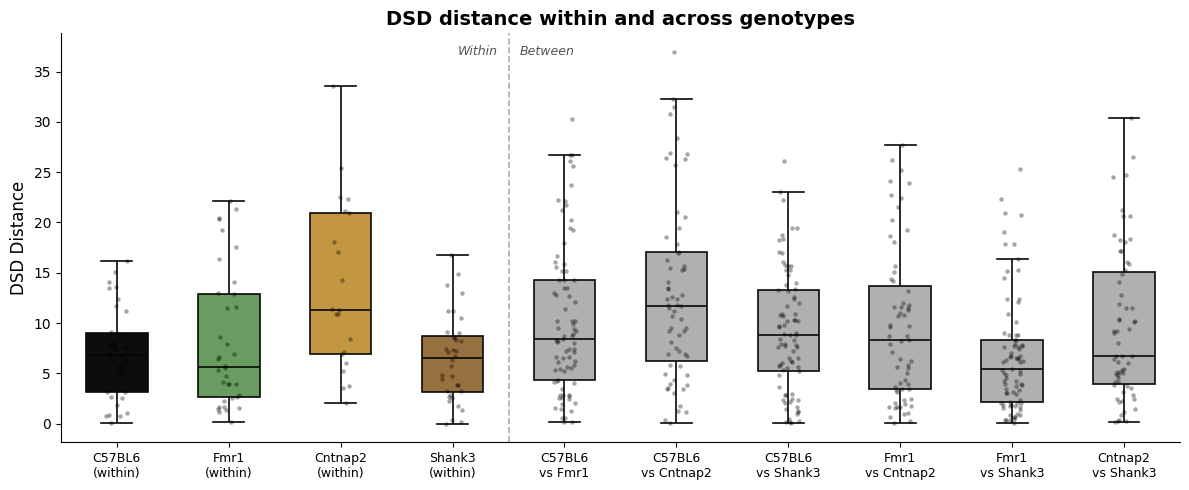

In [115]:

# For each genotype: within-genotype distances vs between-genotype distances
labels_arr = np.array(all_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

colors_map = {'N': '#0D0D0D', 'F': '#61A656', 'C': '#D99C2B', 'S': '#A67232'}
map_labels_local = {'C': 'Cntnap2', 'F': 'Fmr1', 'N': 'C57BL6', 'S': 'Shank3'}

# Build all pairwise records
records = []
for i, g1 in enumerate(genotype_order):
    for j, g2 in enumerate(genotype_order):
        if i > j:
            continue
        if g1 == g2:
            vals = within_distance(dist_neural, labels_arr, g1)
            label = f'{map_labels_local[g1]}\n(within)'
            kind = 'within'
        else:
            vals = across_distance(dist_neural, labels_arr, g1, g2)
            label = f'{map_labels_local[g1]}\nvs {map_labels_local[g2]}'
            kind = 'between'
        for v in vals:
            records.append({'distance': v, 'comparison': label, 'kind': kind, 'g1': g1, 'g2': g2})

df_pairs = pd.DataFrame(records)

within_labels = [f'{map_labels_local[g]}\n(within)' for g in genotype_order]
between_labels = [
    f'{map_labels_local[g1]}\nvs {map_labels_local[g2]}'
    for i, g1 in enumerate(genotype_order)
    for j, g2 in enumerate(genotype_order)
    if i < j
]
comparison_order = within_labels + between_labels

# Color per comparison: genotype color for within, muted gray for between
box_colors = []
for lbl in comparison_order:
    row = df_pairs[df_pairs['comparison'] == lbl].iloc[0]
    box_colors.append(colors_map[row['g1']] if row['kind'] == 'within' else '#B0B0B0')

fig, ax = plt.subplots(figsize=(12, 5))

bp = sns.boxplot(
    x='comparison', y='distance', data=df_pairs,
    order=comparison_order,
    hue='comparison', hue_order=comparison_order,
    palette=dict(zip(comparison_order, box_colors)),
    showfliers=False, width=0.55, linewidth=1.2,
    legend=False, ax=ax,
)
sns.stripplot(
    x='comparison', y='distance', data=df_pairs,
    order=comparison_order,
    color='black', alpha=0.35, size=3.2, jitter=True, ax=ax,
)

# Vertical separator between within and between groups
sep_x = len(within_labels) - 0.5
ymin, ymax = ax.get_ylim()
ax.axvline(sep_x, color='#888888', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(sep_x - 0.1, ymax * 0.97, 'Within', ha='right', va='top',
        fontsize=9, color='#555555', style='italic')
ax.text(sep_x + 0.1, ymax * 0.97, 'Between', ha='left', va='top',
        fontsize=9, color='#555555', style='italic')

ax.set_title('DSD distance within and across genotypes', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('DSD Distance', fontsize=12)
ax.tick_params(axis='x', labelsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


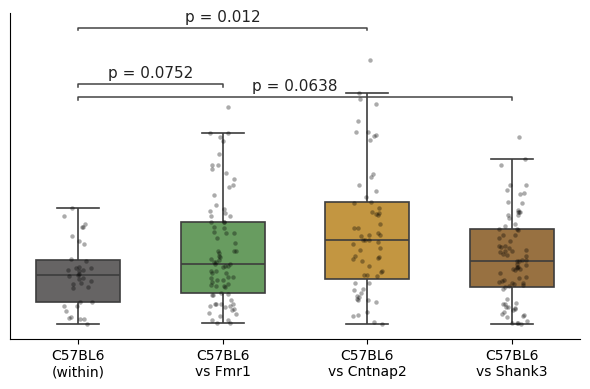

In [163]:
colors_map = {'N': '#666464FF', 'F': '#61A656', 'C': '#D99C2B', 'S': '#A67232'}
map_labels_local = {'C': 'Cntnap2', 'F': 'Fmr1', 'N': 'C57BL6', 'S': 'Shank3'}

# Here, doing the same but just for control-to-others
labels_arr = np.array(all_genotypes)
ref_gen = 'N'

# Keep the genotype order consistent with the notebook
other_gens = [g for g in ['F', 'C', 'S'] if g in labels_arr]


def permutation_gen(dist_matrix, g1, g2, labels, n_perms=10000, random_state=42):
    labels = np.asarray(labels)
    subset_mask = np.isin(labels, [g1, g2])
    subset_labels = labels[subset_mask]
    subset_dist = dist_matrix[np.ix_(subset_mask, subset_mask)]

    obs_diff = across_distance(subset_dist, subset_labels, g1, g2).mean() - within_distance(subset_dist, subset_labels, g1).mean()

    rng = np.random.default_rng(random_state)
    perm_diffs = np.empty(n_perms, dtype=float)
    for idx in range(n_perms):
        perm_labels = rng.permutation(subset_labels)
        perm_diffs[idx] = across_distance(subset_dist, perm_labels, g1, g2).mean() - within_distance(subset_dist, perm_labels, g1).mean()

    p_value = (np.sum(perm_diffs >= obs_diff) + 1) / (n_perms + 1)
    return obs_diff, perm_diffs, p_value



records = []
p_values = {}

# C57BL6 within-subject-pairs
within_vals = within_distance(dist_neural, labels_arr, ref_gen)
within_label = f"{map_labels_local[ref_gen]}\n(within)"
for v in within_vals:
    records.append({
        'distance': v,
        'comparison': within_label,
        'kind': 'within',
        'pair': f'{ref_gen}-{ref_gen}',
    })

# C57BL6 vs each other genotype
for g in other_gens:
    vals = across_distance(dist_neural, labels_arr, ref_gen, g)
    comparison_label = f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}"
    for v in vals:
        records.append({
            'distance': v,
            'comparison': comparison_label,
            'kind': 'between',
            'pair': f'{ref_gen}-{g}',
        })

    obs_diff, perm_diffs, p_val = permutation_gen(
        dist_neural, ref_gen, g, labels_arr, n_perms=10000, random_state=42
    )
    p_values[comparison_label] = {'p_value': p_val, 'obs_diff': obs_diff}

df_n_focus = pd.DataFrame(records)

comparison_order = [within_label] + [
    f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}" for g in other_gens
]

palette = {comparison_order[0]: colors_map[ref_gen]}
for g in other_gens:
    palette[f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}"] = colors_map[g]

fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=df_n_focus,
    x='comparison', y='distance',
    order=comparison_order,
    hue='comparison', hue_order=comparison_order,
    palette=palette,
    showfliers=False,
    width=0.58,
    linewidth=1.2,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=df_n_focus,
    x='comparison', y='distance',
    order=comparison_order,
    color='black', alpha=0.33, size=3.2, jitter=True,
    ax=ax,
)

counts = df_n_focus.groupby('comparison').size().reindex(comparison_order)
ymin, ymax = ax.get_ylim()
y_range = ymax - ymin
y_text = ymin + 0.05 * y_range
"""for i, label in enumerate(comparison_order):
    ax.text(i, y_text, f"n={counts[label]}", ha='center', va='bottom', fontsize=9, color='#444444')
"""
# Add pairwise p-values against the C57BL6 within distribution
for idx, label in enumerate(comparison_order[1:], start=1):
    y_group_max = df_n_focus.loc[df_n_focus['comparison'].isin([within_label, label]), 'distance'].max()
    y_bar = y_group_max + (0.08 + 0.03 * (idx - 1)) * y_range
    ax.plot([0, 0, idx, idx], [y_bar - 0.01 * y_range, y_bar, y_bar, y_bar - 0.01 * y_range],
            color='#444444', linewidth=1.1)
    ax.text(
        (0 + idx) / 2,
        y_bar + 0.01 * y_range,
        f"p = {p_values[label]['p_value']:.3g}",
        ha='center',
        va='bottom',
        fontsize=11,
        color='#222222'
    )

#ax.set_title('C57BL6 within vs across genotypes', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('', fontsize=12)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=10)
sns.despine(ax=ax)
plt.tight_layout()

plt.savefig(f"control_vs_across_genotypes.svg", dpi=300, bbox_inches='tight')
plt.show()

In [158]:
for g in other_gens:
    obs_diff, perm_diffs, p_value = permutation_gen(dist_neural, 'N', g, labels_arr, n_perms=10000, random_state=42)
    print(f"Observed difference between N and {g}: {obs_diff:.4f}, p-value: {p_value:.4f}")


Observed difference between N and F: 3.2829, p-value: 0.0752
Observed difference between N and C: 5.9543, p-value: 0.0120
Observed difference between N and S: 2.2444, p-value: 0.0638


C57BL6: mean diff observed = 3.6570, p = 0.0190
Fmr1: mean diff observed = 0.6635, p = 0.3660
Cntnap2: mean diff observed = -2.7547, p = 0.9080
Shank3: mean diff observed = 1.9527, p = 0.1400


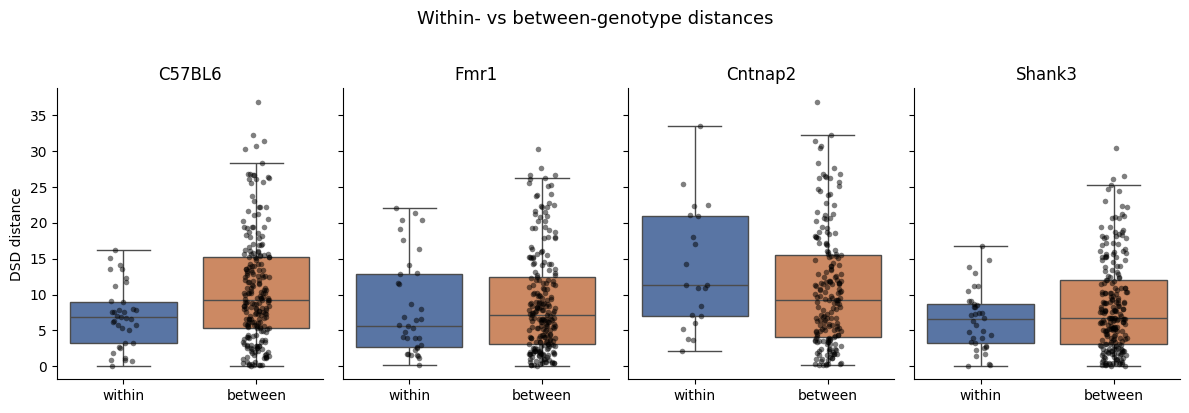

In [159]:

# For each genotype: within-genotype distances vs between-genotype distances
labels_arr = np.array(all_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

df_dist = get_distance_records(dist_neural, labels_arr)
df_dist = pd.DataFrame(df_dist)

# permutation test for each genotype
for g in genotype_order:
    obs = per_genotype_stat(dist_neural, labels_arr, g)
    perm_stats_g = np.array([per_genotype_stat(dist_neural, np.random.permutation(labels_arr), g) for _ in range(1000)])
    p_val = np.mean(perm_stats_g >= obs)
    print(f"{map_labels.get(g, g)}: mean diff observed = {obs:.4f}, p = {p_val:.4f}")

palette = {'within': '#4C72B0', 'between': '#DD8452'}

fig, axes = plt.subplots(1, len(genotype_order), figsize=(3 * len(genotype_order), 4), sharey=True)
if len(genotype_order) == 1:
    axes = [axes]

for ax, g in zip(axes, genotype_order):
    df_g = df_dist[df_dist['genotype'] == g]
    sns.boxplot(data=df_g, x='kind', y='distance', hue='kind', order=['within', 'between'],
                   palette=palette, showfliers=False, ax=ax)
    sns.stripplot(data=df_g, x='kind', y='distance', order=['within', 'between'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)
    ax.set_title(map_labels.get(g, g), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('DSD distance' if g == genotype_order[0] else '')

plt.suptitle('Within- vs between-genotype distances', fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(f"within_vs_between_genotype_distances.svg", dpi=300, bbox_inches='tight')
plt.show()


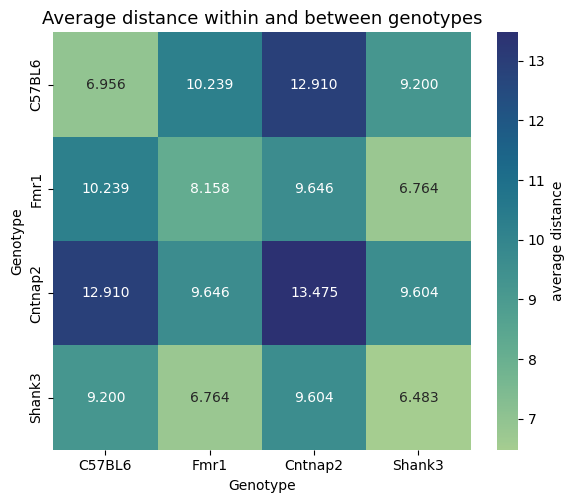

In [160]:
# Pairwise matrix: row i measures the mean distance between subjects from genotype i and subjects from genotype j
labels_arr = np.array(all_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

def mean_within_distance(dist_matrix, labels, g):
    idx = np.where(labels == g)[0]
    block = dist_matrix[np.ix_(idx, idx)] # index this block
    tri = np.triu_indices(len(idx), k=1)
    vals = block[tri]
    return vals.mean() if len(vals) > 0 else np.nan

# Compute the mean distance between genotypes g_i and g_j
def mean_distance(dist_matrix, labels, g_i, g_j):
    idx_i = np.where(labels == g_i)[0]
    idx_j = np.where(labels == g_j)[0]
    if g_i == g_j:
        return mean_within_distance(dist_matrix, labels, g_i)
    vals = dist_matrix[np.ix_(idx_i, idx_j)].ravel() # index this block and flatten
    return vals.mean() if len(vals) > 0 else np.nan

n_g = len(genotype_order)

diff_matrix = np.full((n_g, n_g), np.nan)
p_matrix = np.full((n_g, n_g), np.nan)

for i, gi in enumerate(genotype_order):
    for j, gj in enumerate(genotype_order):

        mean = mean_distance(dist_neural, labels_arr, gi, gj)
        diff_matrix[i, j] = mean

label_names = [map_labels.get(g, g) for g in genotype_order]

fig, ax = plt.subplots( figsize=(6, 5))

# Heatmap : Mean distance within or between genotypes 
sns.heatmap(
    diff_matrix,
    ax=ax,
    cmap='crest',
    annot=True,
    fmt='.3f',
    xticklabels=label_names,
    yticklabels=label_names,
    square=True,
    cbar_kws={'label': 'average distance'},
)
ax.set_title('Average distance within and between genotypes', fontsize=13)
ax.set_xlabel('Genotype')
ax.set_ylabel('Genotype')

plt.tight_layout()
plt.show()

In [161]:
# How to test whether the distance between genotypes is significant? 
# I can do a permutation test where I shuffle the genotype labels and recompute the distance matrix

# Null hypothesis: the distance between genotypes is not different from the distance within genotypes

labels = np.array(all_genotypes)
n_perms=10000
p_value, perm_stats, obs_stat = permutation_test(dist_neural, labels, n_perms=n_perms)


Observed statistic (between - within): 2.3395
p-value: 0.0114


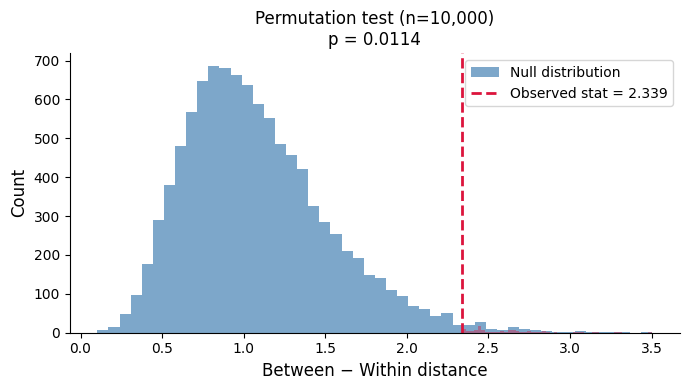

In [162]:
# Visualize the null distribution and observed statistic
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
ax.axvline(obs_stat, color='crimson', linewidth=2, linestyle='--', label=f'Observed stat = {obs_stat:.3f}')

# Shade the tail (p-value region)
tail = perm_stats[perm_stats >= obs_stat]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.4)

ax.set_xlabel('Between − Within distance', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Permutation test (n={n_perms:,})\np = {p_value:.4f}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

Global PERMANOVA (all genotypes): pseudo-F = 3.2871, p = 0.019598


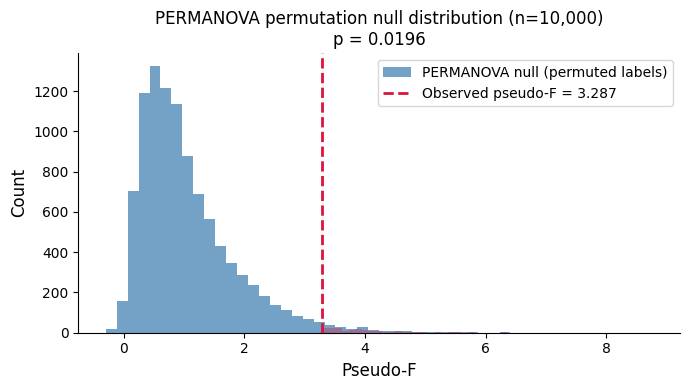

C57BL6 vs others: pseudo-F = 9.9517, p = 0.001900
Fmr1 vs others: pseudo-F = 0.6847, p = 0.463054
Cntnap2 vs others: pseudo-F = 1.7976, p = 0.173583
Shank3 vs others: pseudo-F = 0.6811, p = 0.466353


,genotype,pseudo_F,p_value,n_in,n_out
0,N,9.951744,0.001900,9,25
2,C,1.797592,0.173583,7,27
1,F,0.684715,0.463054,9,25
3,S,0.681080,0.466353,9,25


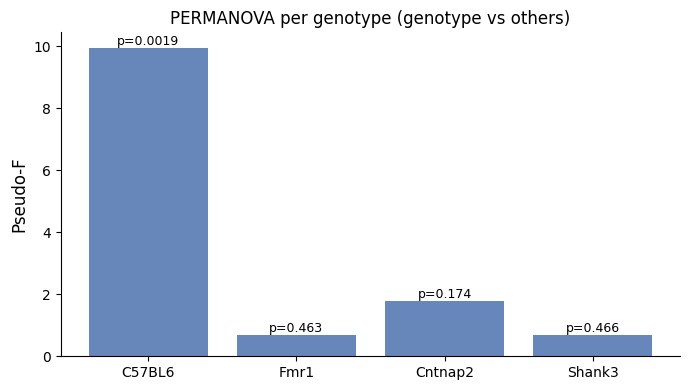

In [70]:
# PERMANOVA with explicit null-distribution plotting
from skbio.stats.distance import DistanceMatrix, permanova

def permanova_with_null(dm, grouping, n_perms=10000, random_state=42):
    """Run PERMANOVA and build a null distribution of pseudo-F by label permutation."""
    rng = np.random.default_rng(random_state)
    grouping = np.asarray(grouping)

    # Observed pseudo-F with no internal permutations
    obs_res = permanova(dm, grouping, permutations=0)
    obs_F = float(obs_res['test statistic'])

    # Null distribution: permute group labels and recompute pseudo-F
    null_F = np.empty(n_perms, dtype=float)
    for k in range(n_perms):
        perm_grouping = rng.permutation(grouping)
        perm_res = permanova(dm, perm_grouping, permutations=0)
        null_F[k] = float(perm_res['test statistic'])

    # +1 correction to avoid exact zero p-values
    p_value = (np.sum(null_F >= obs_F) + 1) / (n_perms + 1)
    return obs_F, null_F, p_value

# Build distance matrix object
dist_neural_sym = (dist_neural + dist_neural.T) / 2
dist_neural_sym[np.diag_indices_from(dist_neural_sym)] = 0
S = dist_neural_sym.shape[0]
ids = [str(i) for i in range(S)]
dm = DistanceMatrix(dist_neural_sym, ids=ids)

labels = np.array(all_genotypes)
n_perms_perm = 10000

# Global PERMANOVA across all genotypes
obs_F_global, null_F_global, p_global = permanova_with_null(dm, labels, n_perms=n_perms_perm, random_state=42)
print(f"Global PERMANOVA (all genotypes): pseudo-F = {obs_F_global:.4f}, p = {p_global:.6f}")

# Plot null distribution for global PERMANOVA
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_F_global, bins=50, color='steelblue', alpha=0.75, label='PERMANOVA null (permuted labels)')
ax.axvline(obs_F_global, color='crimson', linestyle='--', linewidth=2, label=f'Observed pseudo-F = {obs_F_global:.3f}')
tail = null_F_global[null_F_global >= obs_F_global]
if len(tail) > 0:
    ax.hist(tail, bins=50, color='crimson', alpha=0.35)
ax.set_xlabel('Pseudo-F', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'PERMANOVA permutation null distribution (n={n_perms_perm:,})\np = {p_global:.4g}', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Per-genotype PERMANOVA: each genotype vs all others
genotype_results = []
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels]

for g in genotype_order:
    grouping_binary = np.where(labels == g, g, 'Other')

    n_in = np.sum(grouping_binary == g)
    n_out = np.sum(grouping_binary == 'Other')
    if n_in < 2 or n_out < 2:
        print(f"Skipping {g}: insufficient samples (in={n_in}, out={n_out})")
        continue

    obs_F_g, null_F_g, p_g = permanova_with_null(
        dm, grouping_binary, n_perms=n_perms_perm, random_state=42
    )
    genotype_results.append({'genotype': g, 'pseudo_F': obs_F_g, 'p_value': p_g, 'n_in': int(n_in), 'n_out': int(n_out)})
    print(f"{map_labels.get(g, g)} vs others: pseudo-F = {obs_F_g:.4f}, p = {p_g:.6f}")

df_permanova_genotype = pd.DataFrame(genotype_results)
display(df_permanova_genotype.sort_values('p_value'))

# Optional summary plot for per-genotype pseudo-F and p-values
if len(df_permanova_genotype) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    x_labels = [map_labels.get(g, g) for g in df_permanova_genotype['genotype']]
    bars = ax.bar(x_labels, df_permanova_genotype['pseudo_F'], color='#4C72B0', alpha=0.85)

    for bar, p_g in zip(bars, df_permanova_genotype['p_value']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"p={p_g:.3g}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_ylabel('Pseudo-F', fontsize=12)
    ax.set_title('PERMANOVA per genotype (genotype vs others)', fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

### Combined plot

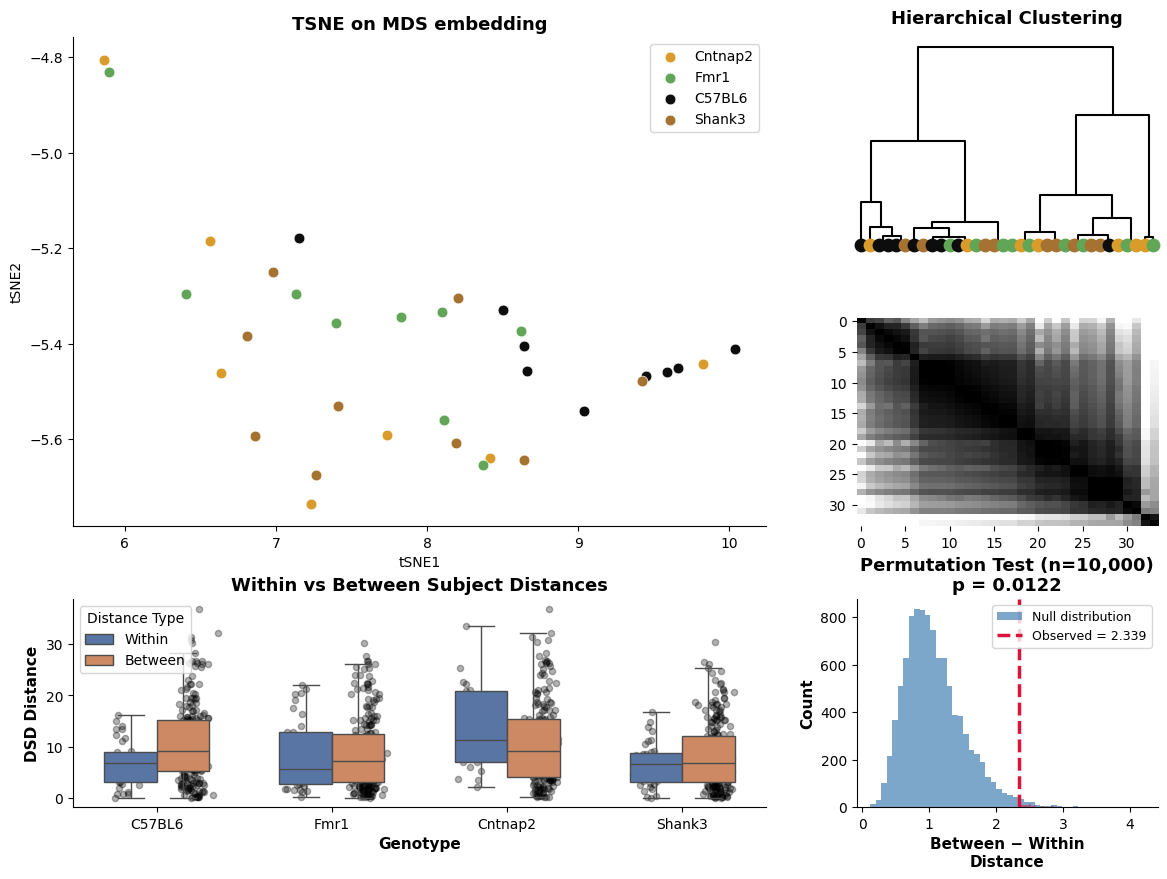

In [72]:
def create_comprehensive_figure(dist_neural, all_genotypes, all_subjects, perm_stats=None, obs_stat=None, n_perms=None):
    """
    Create a comprehensive multi-axes figure combining:
    - PCA on MDS embedding
    - Hierarchical clustering
    - Boxplot of within vs between distances per genotype
    - Histogram of permutation test statistics
    """
    labels = np.array(all_genotypes)
    colors_map = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}
    genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels]
    
    # Create figure with specific layout
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # PCA on MDS embedding (large plot on the left)
    ax_pca = fig.add_subplot(gs[0:2, 0:2])
    ax_pca = plot_mds_tsne(dist_neural, labels, ax=ax_pca, perplexity=25)
    #ax_pca.set_xticks([])
    #ax_pca.set_yticks([])
    ax_pca.legend(loc='best', fontsize=10)
    sns.despine(ax=ax_pca)
    
    # Hierarchical clustering heatmap (top right)
    ax_dendro = fig.add_subplot(gs[0, 2])
    ax_heatmap = fig.add_subplot(gs[1, 2])
    
    S = dist_neural.shape[0]
    dist_neural_flat = dist_neural[np.triu_indices(S, 1)]
    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    
    dn = hierarchy.dendrogram(linkage, ax=ax_dendro, color_threshold=0, 
                               above_threshold_color='k', no_labels=True)
    ax_dendro.axis('off')
    ax_dendro.set_title('Hierarchical Clustering', fontsize=13, fontweight='bold', pad=10)
    
    leaf_order = hierarchy.leaves_list(hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat))
    x_coords = np.arange(5, S * 10 + 5, 10)
    
    for i, original_idx in enumerate(leaf_order):
        lab = labels[original_idx]
        color = colors_map[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=80, zorder=10, clip_on=False)
    
    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    im = ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto',
                           vmin=np.percentile(ordered_dist, 5), 
                           vmax=np.percentile(ordered_dist, 95))
    #ax_heatmap.set_xticks([])
    #ax_heatmap.set_yticks([])
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)
    
    # Boxplot: within vs between per genotype (middle left and middle center)
    ax_box = fig.add_subplot(gs[2, 0:2])
    
    records = []
    S_fc = dist_neural.shape[0]
    for i in range(S_fc):
        for j in range(i + 1, S_fc):
            if labels[i] == labels[j]:
                records.append({'genotype': labels[i], 'kind': 'Within', 'distance': dist_neural[i, j]})
            else:
                records.append({'genotype': labels[i], 'kind': 'Between', 'distance': dist_neural[i, j]})
                records.append({'genotype': labels[j], 'kind': 'Between', 'distance': dist_neural[i, j]})
    
    df_dist = pd.DataFrame(records)
    
    # Filter and plot
    plot_order = [g for g in genotype_order if g in df_dist['genotype'].values]
    sns.boxplot(data=df_dist, x='genotype', y='distance', hue='kind', 
                order=plot_order, hue_order=['Within', 'Between'],
                palette={'Within': '#4C72B0', 'Between': '#DD8452'},
                showfliers=False, ax=ax_box, width=0.6)
    
    # Plot individual points for within/between distributions
    within_df = df_dist[df_dist['kind'] == 'Within']
    between_df = df_dist[df_dist['kind'] == 'Between']
    
    for i, g in enumerate(plot_order):
        w_data = within_df[within_df['genotype'] == g]['distance'].values
        b_data = between_df[between_df['genotype'] == g]['distance'].values
        
        x_jitter_w = np.random.normal(i - 0.2, 0.04, size=len(w_data))
        x_jitter_b = np.random.normal(i + 0.2, 0.04, size=len(b_data))
        
        ax_box.scatter(x_jitter_w, w_data, color='black', alpha=0.3, s=20, zorder=1)
        ax_box.scatter(x_jitter_b, b_data, color='black', alpha=0.3, s=20, zorder=1)
    
    ax_box.set_xlabel('Genotype', fontsize=11, fontweight='bold')
    ax_box.set_ylabel('DSD Distance', fontsize=11, fontweight='bold')
    ax_box.set_title('Within vs Between Subject Distances', fontsize=13, fontweight='bold')
    ax_box.set_xticks(range(len(plot_order)))
    ax_box.set_xticklabels([map_labels.get(g, g) for g in plot_order], fontsize=10)
    ax_box.legend(title='Distance Type', fontsize=10, title_fontsize=10, loc='upper left')
    sns.despine(ax=ax_box)
    
    # Histogram of permutation test (middle right)
    ax_hist = fig.add_subplot(gs[2, 2])
    
    if perm_stats is not None and obs_stat is not None:
        ax_hist.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, label='Null distribution')
        ax_hist.axvline(obs_stat, color='crimson', linewidth=2.5, linestyle='--', 
                        label=f'Observed = {obs_stat:.3f}')
        
        # Shade the tail
        tail = perm_stats[perm_stats >= obs_stat]
        if len(tail) > 0:
            ax_hist.hist(tail, bins=50, color='crimson', alpha=0.5)
        
        p_value = np.mean(perm_stats >= obs_stat)
        ax_hist.set_xlabel('Between − Within\nDistance', fontsize=11, fontweight='bold')
        ax_hist.set_ylabel('Count', fontsize=11, fontweight='bold')
        ax_hist.set_title(f'Permutation Test (n={n_perms:,})\np = {p_value:.4f}', 
                         fontsize=13, fontweight='bold')
        ax_hist.legend(fontsize=9, loc='upper right')
        sns.despine(ax=ax_hist)
    
    return fig

# Create the comprehensive figure
fig = create_comprehensive_figure(dist_neural, all_genotypes, all_subjects, 
                                   perm_stats, obs_stat, n_perms)

fig.savefig('clustering_genotypes.svg', dpi=300, bbox_inches='tight')
plt.show()

### Sillouette

With this, I wanted to see if i could clearly, based on the distance matrix, clusterize the different populations. However, indeed, from what I can see directly from the figure, the clusters are not very clear. Knowing the genotypes of each point i can find some correlation, but 

k=2: silhouette score = 0.5723
k=3: silhouette score = 0.5086
k=4: silhouette score = 0.5863
k=5: silhouette score = 0.5582
k=6: silhouette score = 0.4767
k=7: silhouette score = 0.5618


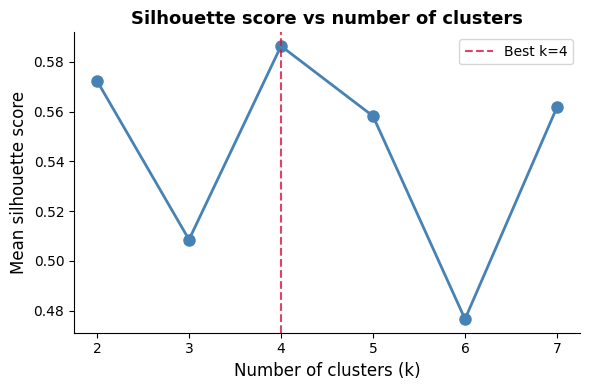

In [20]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# Symmetrize the distance matrix 

# Remove 15 and 19 because they are outliers and mess with the clustering
dist_neural_rem = np.delete(dist_neural, [15, 19], axis=0)
dist_neural_rem = np.delete(dist_neural_rem, [15, 19], axis=1)
labels_arr = np.delete(labels_arr, [15, 19])

dist_sym = (dist_neural_rem + dist_neural_rem.T) / 2
np.fill_diagonal(dist_sym, 0)

k_range = range(2, 8)
sil_scores = []

for k in k_range:
    clust = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_clust = clust.fit_predict(dist_sym)
    score = silhouette_score(dist_sym, labels_clust, metric='precomputed')
    sil_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = list(k_range)[np.argmax(sil_scores)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(k_range), sil_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(best_k, color='crimson', linestyle='--', alpha=0.8, label=f'Best k={best_k}')
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Mean silhouette score', fontsize=12)
ax.set_title('Silhouette score vs number of clusters', fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1551463/813931391.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


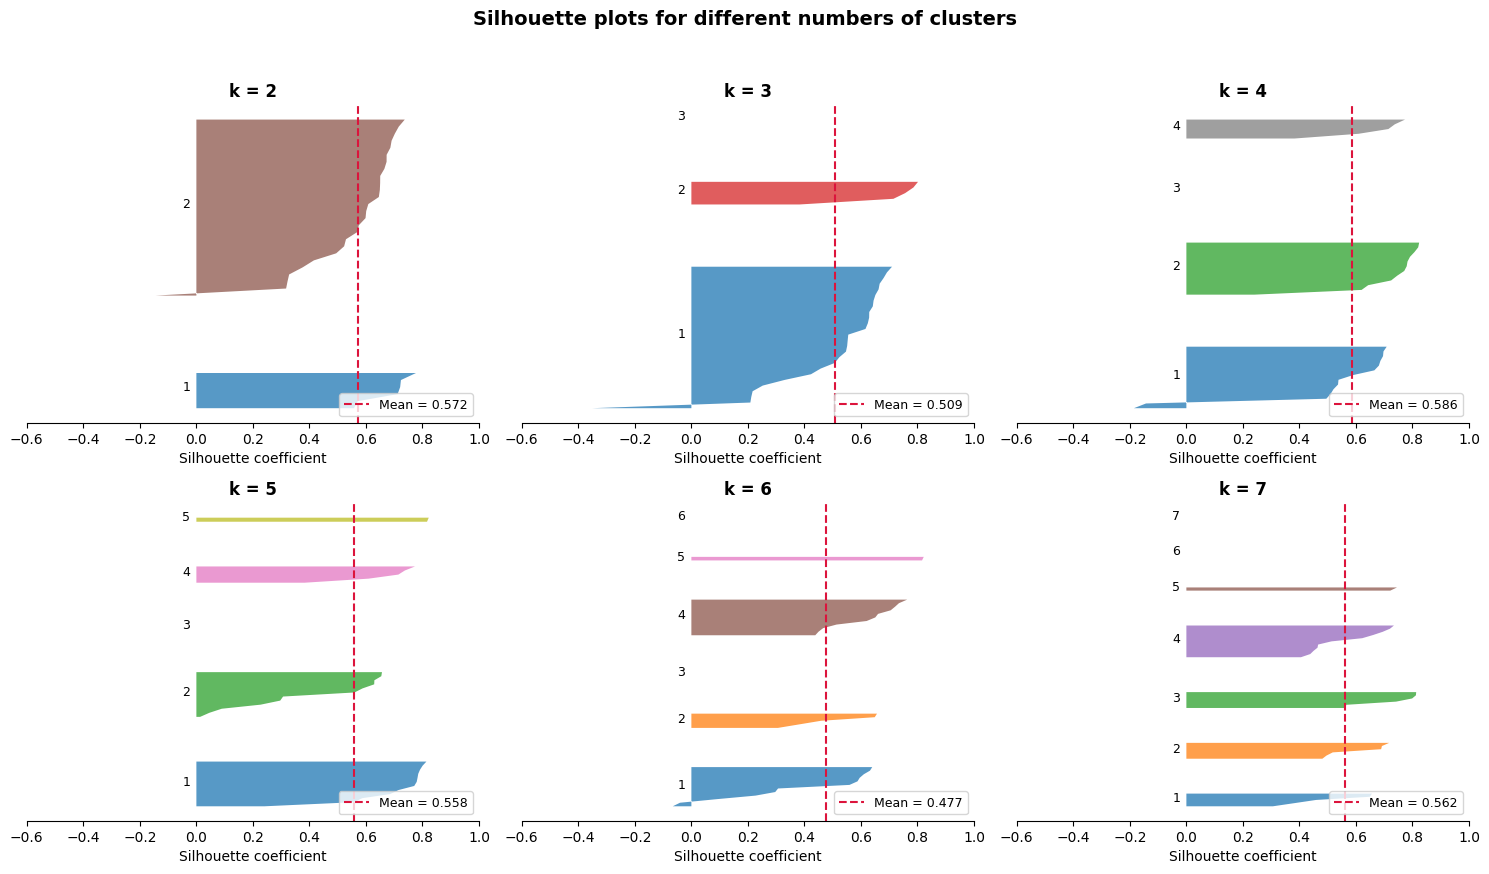

In [21]:

# Individual silhouette plots for each k
n_ks = len(list(k_range))
n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

colors_genotype = {'N': '#0D0D0D', 'F': '#61A656', 'C': '#D99C2B', 'S': '#A67232'}
cmap = cm.get_cmap('tab10')

for idx, k in enumerate(k_range):
    ax = axes[idx]
    clust = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_clust = clust.fit_predict(dist_sym)
    sil_vals = silhouette_samples(dist_sym, labels_clust, metric='precomputed')
    score = silhouette_score(dist_sym, labels_clust, metric='precomputed')

    y_lower = 10
    for c in range(k):
        c_mask = labels_clust == c
        c_sil = np.sort(sil_vals[c_mask])
        y_upper = y_lower + c_sil.shape[0]
        color = cmap(c / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, facecolor=color, alpha=0.75)
        ax.text(-0.05, y_lower + 0.5 * c_sil.shape[0], str(c + 1), fontsize=9, va='center')
        y_lower = y_upper + 10

    ax.axvline(score, color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {score:.3f}')
    ax.set_xlim([-0.6, 1.0])
    ax.set_yticks([])
    ax.set_xlabel('Silhouette coefficient', fontsize=10)
    ax.set_title(f'k = {k}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    sns.despine(ax=ax, left=True)

for idx in range(n_ks, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Silhouette plots for different numbers of clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [24]:
# Inspect which points belong to each cluster for a chosen k
# Use best_k from the silhouette sweep, or set k manually here.
k_inspect = best_k

clust = AgglomerativeClustering(n_clusters=k_inspect, metric='precomputed', linkage='average')
cluster_labels = clust.fit_predict(dist_sym)

cluster_membership = pd.DataFrame({
    'point_idx': np.arange(len(labels_arr)),
    'genotype': labels_arr,
    'cluster': cluster_labels,
})

# Sort so each cluster is easy to scan
cluster_membership = cluster_membership.sort_values(['cluster', 'genotype', 'point_idx']).reset_index(drop=True)

display(cluster_membership)

print('Counts per cluster and genotype:')
display(pd.crosstab(cluster_membership['cluster'], cluster_membership['genotype']))

for c_id in sorted(cluster_membership['cluster'].unique()):
    df_c = cluster_membership[cluster_membership['cluster'] == c_id]
    print(f'\nCluster {c_id} (n={len(df_c)}):')
    print('  genotypes:', df_c['genotype'].value_counts().to_dict())
    print('  points:', df_c['point_idx'].tolist())

,point_idx,genotype,cluster
0,17,C,0
1,19,C,0
2,21,C,0
3,22,C,0
4,9,F,0
5,10,F,0
6,12,F,0
7,16,F,0
8,1,N,0
9,23,S,0


Counts per cluster and genotype:


genotype,C,F,N,S
cluster,,,,
0,4,4,1,5
1,1,4,4,3
2,0,0,1,0
3,1,0,3,1



Cluster 0 (n=14):
  genotypes: {'S': 5, 'C': 4, 'F': 4, 'N': 1}
  points: [17, 19, 21, 22, 9, 10, 12, 16, 1, 23, 25, 26, 29, 30]

Cluster 1 (n=12):
  genotypes: {'F': 4, 'N': 4, 'S': 3, 'C': 1}
  points: [20, 11, 13, 14, 15, 5, 6, 7, 8, 24, 27, 31]

Cluster 2 (n=1):
  genotypes: {'N': 1}
  points: [2]

Cluster 3 (n=5):
  genotypes: {'N': 3, 'C': 1, 'S': 1}
  points: [18, 0, 3, 4, 28]


## Combining neural with prior

In [66]:
# Load the prior function for each animal also
genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
genotype_priors = defaultdict(list)
all_animals = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:
        # Contrast kernel
        animal_kernel, animal_prior = load_animal_kernels(g, regions, animal, load_prior=True) # (n_units, n_contrasts, n_time_bins=106)
        # Filter for outliers
        animal_kernel_filter, animal_prior_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5, prior=animal_prior) # (n_units, n_contrasts, n_time_bins)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)
            genotype_priors[g].append(animal_prior_filter) # (subjects, n_units, timepoints)

In [50]:
genotype_kernels_neurons['N'][1].shape # (n_units, n_contrasts, n_time_bins) for the first animal of N

(821, 9, 106)

In [51]:
genotype_priors['N'][1].shape # (n_units, n_contrasts, n_time_bins) for the first animal of N


(821, 106)

### Shape metrics

In [70]:
from utils import load_animal_region_kernels, load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, load_animal_prior

# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    arrs = genotype_kernels_neurons[g]
    priors = genotype_priors[g]
    #arrs = [a[:,3:6,:] for a in arrs] #[:,3:6,:]
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    idxs = [i for i in range(len(arrs)) if len(arrs[i]) >= 100]
    vals = [arrs[i].reshape(arrs[i].shape[0], -1).T for i in idxs] # (n_neurons, contrast*timepoints) for each subject
    priors = [priors[i] for i in idxs]
    
    # Merge kernels and priors by concatenating on the last axis
    vals = [np.concatenate([vals[i], priors[i].T], axis=0) for i in range(len(vals))]

    # Maybe do a mean across all time points?
    #vals = [a.mean(-1).T for a in arrs if (len(a) >= 100) ] # (n_neurons, contrast) for each subject
    if g=='N':
        # Remove this subject of N because it has a very different activity and messes with the clustering
        vals.pop(-1)

    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)


In [44]:
priors[0].shape

(268, 100)

In [33]:
all_subjects[0].shape 

(1054, 209)

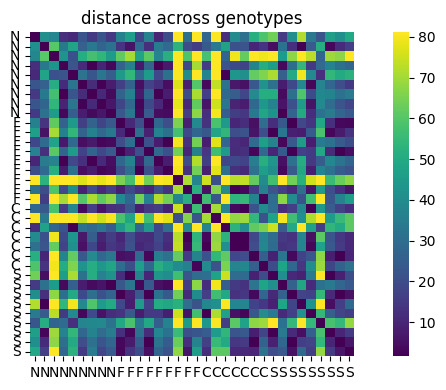

In [71]:

S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i], all_subjects[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

vmin = np.quantile(dist_neural.flatten(), 0.05)  # 5th percentile
vmax = np.quantile(dist_neural.flatten(), 0.95)  # 95th percentile

sns.heatmap(dist_neural, xticklabels=all_genotypes, yticklabels=all_genotypes, cmap='viridis', 
            square=True, fmt='.2f', linecolor='white', norm=Normalize(vmin, vmax))

plt.title('distance across genotypes', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'PCA on MDS embedding'}, xlabel='PC1 (82.2%)', ylabel='PC2 (14.2%)'>

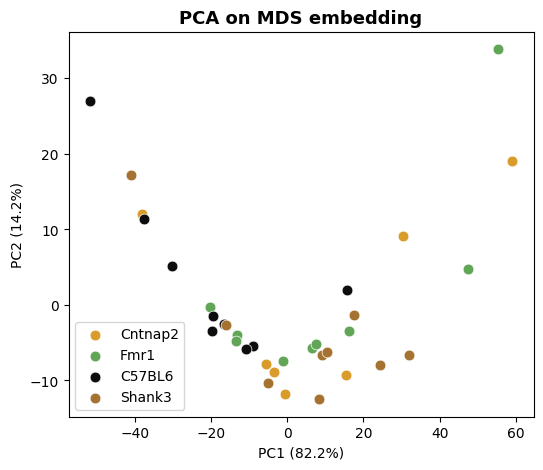

In [72]:
plot_mds_pca(dist_neural, all_genotypes)

<Axes: title={'center': 'TSNE on MDS embedding'}, xlabel='tSNE1', ylabel='tSNE2'>

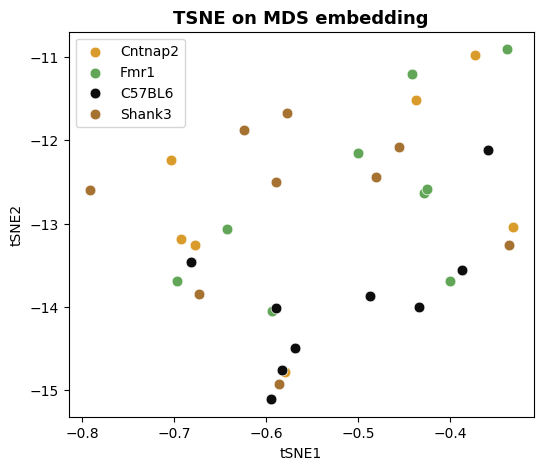

In [73]:
plot_mds_tsne(dist_neural, all_genotypes, n_components=100, perplexity=25)


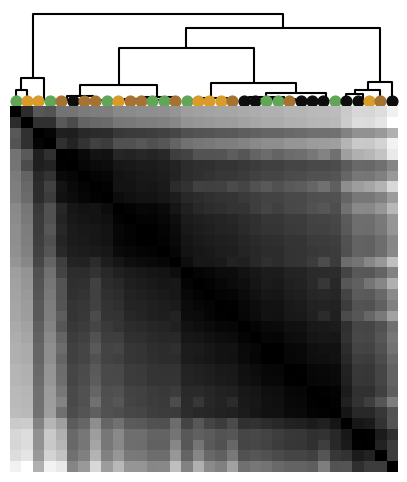

In [74]:
labels_arr = np.array(all_genotypes)
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

plot_dendogram(dist_neural, all_genotypes, lab_to_color=colors)

C57BL6: mean diff observed = 11.3664, p = 0.0250
Fmr1: mean diff observed = -1.8791, p = 0.6260
Cntnap2: mean diff observed = -5.1685, p = 0.7650
Shank3: mean diff observed = 4.1029, p = 0.2280


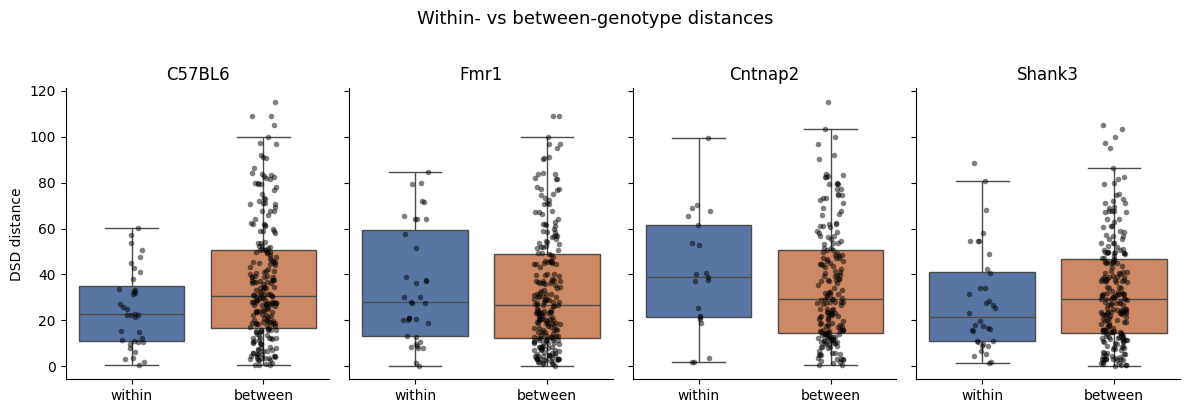

In [75]:

# For each genotype: within-genotype distances vs between-genotype distances
labels_arr = np.array(all_genotypes)
genotype_order = [g for g in ['N', 'F', 'C', 'S'] if g in labels_arr]

df_dist = get_distance_records(dist_neural, labels_arr)
df_dist = pd.DataFrame(df_dist)

# permutation test for each genotype
for g in genotype_order:
    obs = per_genotype_stat(dist_neural, labels_arr, g)
    perm_stats_g = np.array([per_genotype_stat(dist_neural, np.random.permutation(labels_arr), g) for _ in range(1000)])
    p_val = np.mean(perm_stats_g >= obs)
    print(f"{map_labels.get(g, g)}: mean diff observed = {obs:.4f}, p = {p_val:.4f}")

palette = {'within': '#4C72B0', 'between': '#DD8452'}

fig, axes = plt.subplots(1, len(genotype_order), figsize=(3 * len(genotype_order), 4), sharey=True)
if len(genotype_order) == 1:
    axes = [axes]

for ax, g in zip(axes, genotype_order):
    df_g = df_dist[df_dist['genotype'] == g]
    sns.boxplot(data=df_g, x='kind', y='distance', hue='kind', order=['within', 'between'],
                   palette=palette, showfliers=False, ax=ax)
    sns.stripplot(data=df_g, x='kind', y='distance', order=['within', 'between'],
                  color='black', alpha=0.5, size=4, jitter=True, ax=ax)
    ax.set_title(map_labels.get(g, g), fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('DSD distance' if g == genotype_order[0] else '')

plt.suptitle('Within- vs between-genotype distances', fontsize=13, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


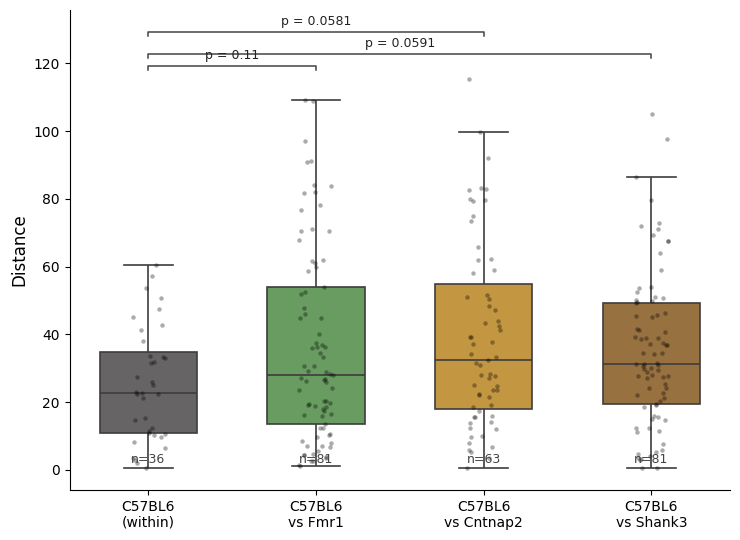

In [76]:
colors_map = {'N': '#666464FF', 'F': '#61A656', 'C': '#D99C2B', 'S': '#A67232'}
map_labels_local = {'C': 'Cntnap2', 'F': 'Fmr1', 'N': 'C57BL6', 'S': 'Shank3'}

# Here, doing the same but just for control-to-others
labels_arr = np.array(all_genotypes)
ref_gen = 'N'

# Keep the genotype order consistent with the notebook
other_gens = [g for g in ['F', 'C', 'S'] if g in labels_arr]


def permutation_gen(dist_matrix, g1, g2, labels, n_perms=10000, random_state=42):
    labels = np.asarray(labels)
    subset_mask = np.isin(labels, [g1, g2])
    subset_labels = labels[subset_mask]
    subset_dist = dist_matrix[np.ix_(subset_mask, subset_mask)]

    obs_diff = across_distance(subset_dist, subset_labels, g1, g2).mean() - within_distance(subset_dist, subset_labels, g1).mean()

    rng = np.random.default_rng(random_state)
    perm_diffs = np.empty(n_perms, dtype=float)
    for idx in range(n_perms):
        perm_labels = rng.permutation(subset_labels)
        perm_diffs[idx] = across_distance(subset_dist, perm_labels, g1, g2).mean() - within_distance(subset_dist, perm_labels, g1).mean()

    p_value = (np.sum(perm_diffs >= obs_diff) + 1) / (n_perms + 1)
    return obs_diff, perm_diffs, p_value



records = []
p_values = {}

# C57BL6 within-subject-pairs
within_vals = within_distance(dist_neural, labels_arr, ref_gen)
within_label = f"{map_labels_local[ref_gen]}\n(within)"
for v in within_vals:
    records.append({
        'distance': v,
        'comparison': within_label,
        'kind': 'within',
        'pair': f'{ref_gen}-{ref_gen}',
    })

# C57BL6 vs each other genotype
for g in other_gens:
    vals = across_distance(dist_neural, labels_arr, ref_gen, g)
    comparison_label = f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}"
    for v in vals:
        records.append({
            'distance': v,
            'comparison': comparison_label,
            'kind': 'between',
            'pair': f'{ref_gen}-{g}',
        })

    obs_diff, perm_diffs, p_val = permutation_gen(
        dist_neural, ref_gen, g, labels_arr, n_perms=10000, random_state=42
    )
    p_values[comparison_label] = {'p_value': p_val, 'obs_diff': obs_diff}

df_n_focus = pd.DataFrame(records)

comparison_order = [within_label] + [
    f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}" for g in other_gens
]

palette = {comparison_order[0]: colors_map[ref_gen]}
for g in other_gens:
    palette[f"{map_labels_local[ref_gen]}\nvs {map_labels_local[g]}"] = colors_map[g]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

sns.boxplot(
    data=df_n_focus,
    x='comparison', y='distance',
    order=comparison_order,
    hue='comparison', hue_order=comparison_order,
    palette=palette,
    showfliers=False,
    width=0.58,
    linewidth=1.2,
    legend=False,
    ax=ax,
)

sns.stripplot(
    data=df_n_focus,
    x='comparison', y='distance',
    order=comparison_order,
    color='black', alpha=0.33, size=3.2, jitter=True,
    ax=ax,
)

counts = df_n_focus.groupby('comparison').size().reindex(comparison_order)
ymin, ymax = ax.get_ylim()
y_range = ymax - ymin
y_text = ymin + 0.05 * y_range
for i, label in enumerate(comparison_order):
    ax.text(i, y_text, f"n={counts[label]}", ha='center', va='bottom', fontsize=9, color='#444444')

# Add pairwise p-values against the C57BL6 within distribution
for idx, label in enumerate(comparison_order[1:], start=1):
    y_group_max = df_n_focus.loc[df_n_focus['comparison'].isin([within_label, label]), 'distance'].max()
    y_bar = y_group_max + (0.08 + 0.03 * (idx - 1)) * y_range
    ax.plot([0, 0, idx, idx], [y_bar - 0.01 * y_range, y_bar, y_bar, y_bar - 0.01 * y_range],
            color='#444444', linewidth=1.1)
    ax.text(
        (0 + idx) / 2,
        y_bar + 0.01 * y_range,
        f"p = {p_values[label]['p_value']:.3g}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='#222222'
    )

#ax.set_title('C57BL6 within vs across genotypes', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Distance', fontsize=12)
ax.tick_params(axis='x', labelsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()